# Lab Guide for Noise Parameter Measurements for any LNA

In this notebook, we will go through the measurements needed to obtain the set of frequency-dependent noise parameters for any LNA. We will use the LNA12 as an example, but the same procedure can be applied to any LNA. 

In general, for any two-port device, we have
$$
F = F_{min} + \frac{R_n}{G_S} |Y_S - Y_{opt}|^2
$$
where F is the noise figure. The set of noise parameters are $\{F_{min}, R_n, Y_{opt}=G_{opt}+jB_{opt}\}$. We can reparameterize so that this becomes linear:
$$ F_i = \vec{A_i} \cdot \vec{x_i}$$
where $\vec{A_i} = [1, \frac{|Y_{S_i}|^2}{G_{S_i}}, \frac{1}{G_{S_i}}, \frac{B_{S_i}}{G_{S_i}}]$.

Regardless, we need to obtain noise emitted by LNA with four different source admittances. To do this, we first need to subtract away any noise contributed by the measurement system itself and any Johnson noise.

In [15]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import skrf as rf
from scipy.constants import Boltzmann as kB

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2


# import relevant classes from highz_exp
from highz_exp.spec_class import Spectrum
from highz_exp.load_trc import TraceLoader
from highz_exp.s_params import S_Params
from highz_exp import plotter, circuit_model, unit_convert
from highz_exp.reflection_proc import reflection_coefficient
import pickle
from highz_exp.fit_temperature import fill_nan_with_fit, NF_Parameters_Fitter


cmap = plt.get_cmap('Accent')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Calibrate away system noise and gain
The first step is to perform two-stage Y-factor measurements to obtain the system noise temperature and gain. This requires another amplifier after the LNA. Details can be found in the [Amplifier Measurement](amplifier_measurements.ipynb) notebook.

In [16]:
data_path = os.path.expanduser("~/Desktop/High-Z/long_cable")

with open(pjoin(data_path, 'LNA12_noise_temp.pkl'), 'rb') as f:
    LNA_temp = pickle.load(f) 

We then need S11 measurements for the four source admittances prepared. In our experiment, the admittances are prepared by terminating an 8' long cable with four different resistors (62.2 Ohm, 99 Ohm, 351 Ohm, 699 Ohm)

In [17]:
# load source S11s
src_s11s = S_Params(s_params_files=[pjoin(data_path, fn) 
    for fn in ['62OHM.S1P', '99OHM.S1P', '351OHM.S1P', '699OHM.S1P']], 
    labels=['62 Ohm', '99 Ohm', '351 Ohm', '699 Ohm'], 
    colorcode=['slategray', 'blue', 'green', 'grey'])

Uncomment the following cell to visualize the four source admittances.

In [18]:
# src_s11s.plot_smith_chart()
# src_s11s.plot_reflection_loss()
# src_s11s.plot_magnitude_phase()

In [19]:
# Make sure all objects have the same frequency axis
resample_freq = LNA_temp.f[(LNA_temp.f >= 25e6) & (LNA_temp.f <= 250e6)]
LNA_temp.resample(resample_freq)
src_s11s.interpolate_all(resample_freq)

# load all relevant system parameters for subtraction away from measurements
system_gain = fill_nan_with_fit(LNA_temp.f, 10**(LNA_temp.g_sys/10))
LNA_noise = fill_nan_with_fit(LNA_temp.f, LNA_temp.T_dut)
system_noise = fill_nan_with_fit(LNA_temp.f, LNA_temp.T_sys) - LNA_noise  # excluding LNA noise contribution

system_noise_spec = Spectrum(LNA_temp.f, system_noise, name='System Noise Temperature', colorcode='red')

# Uncomment below to visualize system_noise
# system_noise_spec.plot(ylabel='Noise Temperature (K)', title='Noise contribution from second-stage amplifier',
#     y_range=(0, 20))

We also need S11 measurement of LNA.

In [20]:
LNA_ntwk = rf.Network(pjoin(data_path, 'LNA12.S1P'))
LNA_ntwk = LNA_ntwk.interpolate(src_s11s.ntwk_dict['351 Ohm'].f)

Use the same measurement system, we then measure spectra for the four different source admittances.

In [56]:
trc_file = pjoin(data_path, "peaks_0521.trc")

loader = TraceLoader(trc_file)
trace = loader.load_trace(1)
ohm_99 = Spectrum(trace[0], trace[1], name='8" Cable - 99 Ohm', colorcode='blue').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_351 = Spectrum(trace[0], trace[1], name='8" Cable - 351 Ohm', colorcode='green').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

trc_file = pjoin(data_path, "peaks_0529.trc")
loader = TraceLoader(trc_file)
trace = loader.load_trace(1)
ohm_62 = Spectrum(trace[0], trace[1], name='8" Cable - 62 Ohm', colorcode='slategray').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_699 = Spectrum(trace[0], trace[1], name='8" Cable - 699 Ohm', colorcode='grey').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

In [57]:
# Uncomment below to visualize the four spectra
# plotter.plot_spectra([ohm_62, ohm_99, ohm_351, ohm_699], title='Measured Spectra for Different Source Admittances',
#     ylabel='Noise Temperature (K)')

We then subtract away system gain and contribution from the second-stage amplifier.

In [58]:
for spec in [ohm_62, ohm_99, ohm_351, ohm_699]:
    spec.resample(LNA_temp.f)
    spec.s = spec.s / system_gain
    spec.s = spec.s - system_noise
    spec = spec.filter_by_spline_fit(inplace=False, rel_tol=0.05)

In [60]:
# Uncomment below to visualize again

# plotter.plot_spectra([ohm_62, ohm_99, ohm_351, ohm_699],
#     title='Measured Spectra (exclude second-stage amplifier contribution)', ls='',
#     ylabel='Noise Temperature (K)', y_range=(0, 2000), marker='o', markersize=2)

## Model and subtract away Johnson noise contribution

We model our set-up with a double emitter circuit, where there are two sources of noise: the noise emitted by the LNA, and the Johnson noise from the source. In order to obtain the LNA contribution, we need to model the Johnson noise contribution and subtract it away. This only requires the source admittance measurements already obtained before. 

In [61]:
def johnson_noise(LNA_S11, src_S11, label, colorcode, delay=18, unit='mm'):
    # calculate a voltage transfer factor
    gamma = - LNA_S11.s[:, 0, 0]
    factor = 1/(4*np.abs(1-gamma)**2*50)
    # factor = 1/(4*(1-np.abs(gamma)**2)*50)
    src_Z = src_S11.z[:, 0, 0]
    LNA_Z = LNA_S11.delay(delay, unit=unit).z[:, 0, 0]
    gamma_1 = (src_Z - LNA_Z) / (LNA_Z + src_Z)
    # power = 300 * kB * 1e6 * (1 - np.abs(gamma_1)**2)
    power = (circuit_model.johnson_V(300, src_Z, 1e6) * np.abs(1-gamma_1))**2
    spec = Spectrum(src_S11.f, power * factor, name=f'{label} Thermal Emission', colorcode=f'light{colorcode}')
    spec = spec.unit_convert(from_unit='watt', to_unit='kelvin', channel_width=1e6)
    return spec

In [62]:
modeled_jn = []

for label, src_s11 in src_s11s.ntwk_dict.items():
    colorcode = src_s11s.colorcode[label]
    jn_spec = johnson_noise(LNA_ntwk, src_s11, label, colorcode, delay=18)
    modeled_jn.append(jn_spec)

At this point, we can start comparing our measured spectra with the modeled Johnson noise. The Johnson noise is the dominant contribution in our measured spectra, so it should be slightly below the measured spectra. Uncomment the following two cells to visualize the comparison.

In [63]:
# plotter.plot_spectra([modeled_jn[0], ohm_62], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 62 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, None), ls='', marker='o', ms=3)

# plotter.plot_spectra([modeled_jn[1], ohm_99], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 99 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, None), ls='', marker='o', ms=3)

In [64]:
# plotter.plot_spectra([modeled_jn[2], ohm_351], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 351 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, 3000), ls='-', marker='o', ms=3)

# plotter.plot_spectra([modeled_jn[3], ohm_699], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 699 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, 3000), ls='-', marker='o', ms=3)

We can then subtract away the Johnson noise contribution to obtain the noise emitted by the LNA and convert that to noise figure.

In [65]:
LNA_contributions = []
for jn_spec, meas_spec in zip(modeled_jn, [ohm_62, ohm_99, ohm_351, ohm_699]):
    LNA_noise = meas_spec.s - jn_spec.s
    LNA_contributions.append(Spectrum(meas_spec.f, LNA_noise, 
        name=f'LNA noise ({meas_spec.name})', colorcode=f'dark{meas_spec.colorcode}'))

Uncomment the following two cells to visualize the LNA noise contribution that are going to be used to extract noise parameters.

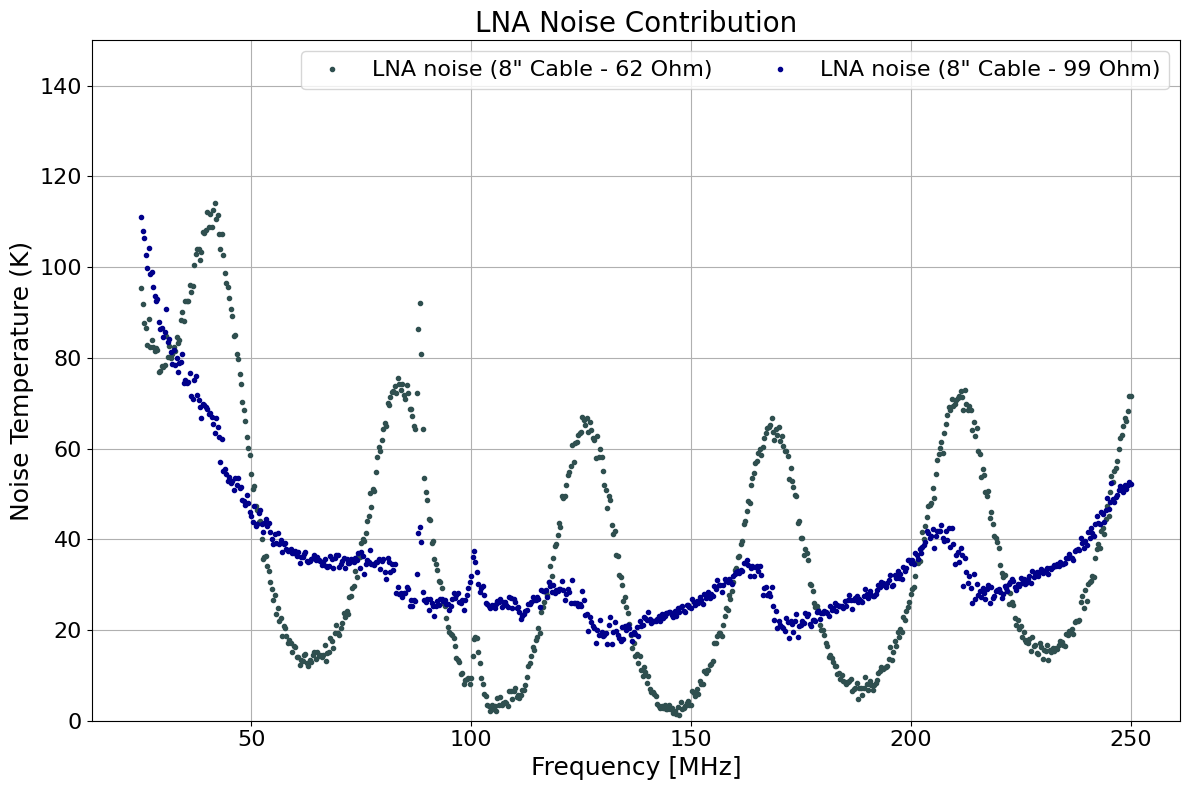

In [66]:
plotter.plot_spectra(LNA_contributions[0:2], 
    title='LNA Noise Contribution',
    ylabel='Noise Temperature (K)', y_range=(0, 150), ls='', marker='o', ms=3)

In [67]:
# plotter.plot_spectra(LNA_contributions[2:4], 
#     title='LNA Noise Contribution',
#     ylabel='Noise Temperature (K)', y_range=(0, 300), ls='', marker='o', ms=3)

The reparameterization is already done in [fit_temperature.py](../src/highz_exp/fit_temperature.py) so that we can obtain a least square solution for a matrix equation.

In [68]:
Y_s = [ntwk.y[:, 0, 0] for ntwk in src_s11s.ntwk_dict.values()]
F = [unit_convert.kelvin_to_NF(spec.s, log=False) for spec in LNA_contributions]
fitter = NF_Parameters_Fitter(Y_s, F)
parameters = fitter.fit_parameters()

Valid points: 2 out of 676


/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/fit_temperature.py:624: RuntimeWarning: invalid value encountered in divide
  self.gamma_opt = (0.02 - self.Y_opt) / (0.02 + self.Y_opt)


In [38]:
frequency_axis = src_s11s.ntwk_dict['351 Ohm'].f
valid_frequency = frequency_axis[fitter.valid_mask]
F_min = fitter.F_min[fitter.valid_mask]
R_n = fitter.R_n[fitter.valid_mask]
Y_opt = fitter.Y_opt[fitter.valid_mask]
gamma_opt = fitter.gamma_opt[fitter.valid_mask]

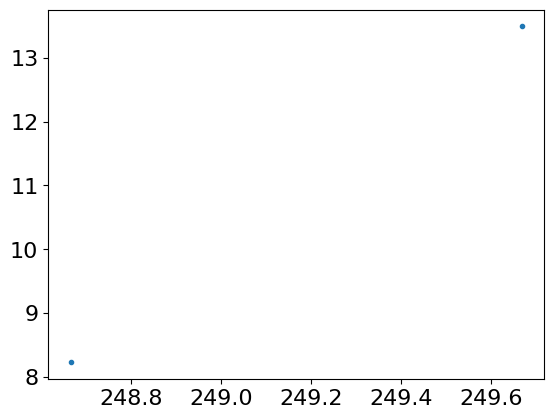

In [39]:
plt.plot(valid_frequency/1e6, R_n, label='R_n', marker='o', ls='', ms=3)

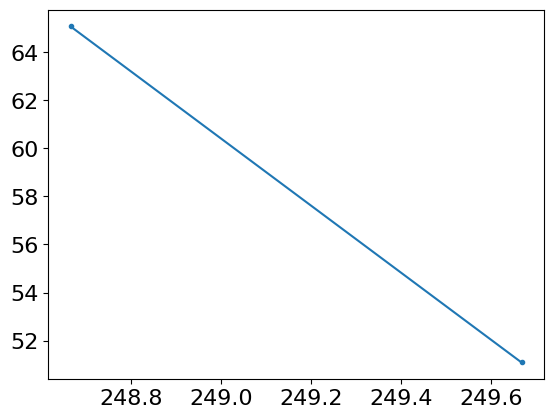

In [40]:
plt.plot(valid_frequency/1e6, np.rad2deg(np.angle(gamma_opt)), marker='o', ms=3, label='Optimal Reflection Coefficient Angle')

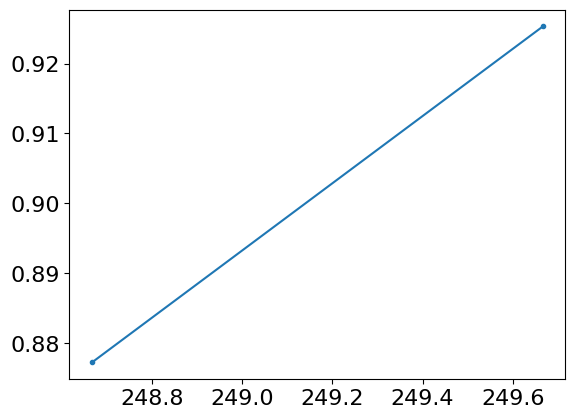

In [41]:
plt.plot(valid_frequency/1e6, np.abs(gamma_opt), marker='o', ms=3, label='Optimal Reflection Coefficient Magnitude')

## Sanity Check 1: Model with a constant $T_{LNA}$

From the system calibrations, we also obtain a LNA noise temperature with a source impedance of 50 Ohm. A primitive model would then only multiply this temperature with a multiple reflection coefficient.

$$
T_{LNA} (\Gamma_s) = T_{LNA} (50 \Omega) \cdot |\frac{\Gamma_{LNA} - \Gamma_s}{\Gamma_{LNA} + \Gamma_s}|^2
$$

In [419]:
def model_LNA_contribution(LNA_S11, load_S11, LNA_noise, label, colorcode): 
    reflect = reflection_coefficient(load_S11, LNA_S11)
    noise = LNA_noise * np.abs(reflect.s[:, 0, 0])**2
    noise_spec = Spectrum(load_S11.f, noise, name=f'Modeled {label} LNA Noise Contribution', colorcode=f'light{colorcode}')
    return noise_spec

In [420]:
modeled_LNA = []
for label, src_s11 in src_s11s.ntwk_dict.items():
    colorcode = src_s11s.colorcode[label]
    LNA_noise = LNA_temp.T_dut
    modeled_spec = model_LNA_contribution(LNA_ntwk, src_s11, LNA_noise, label, colorcode)
    modeled_LNA.append(modeled_spec)

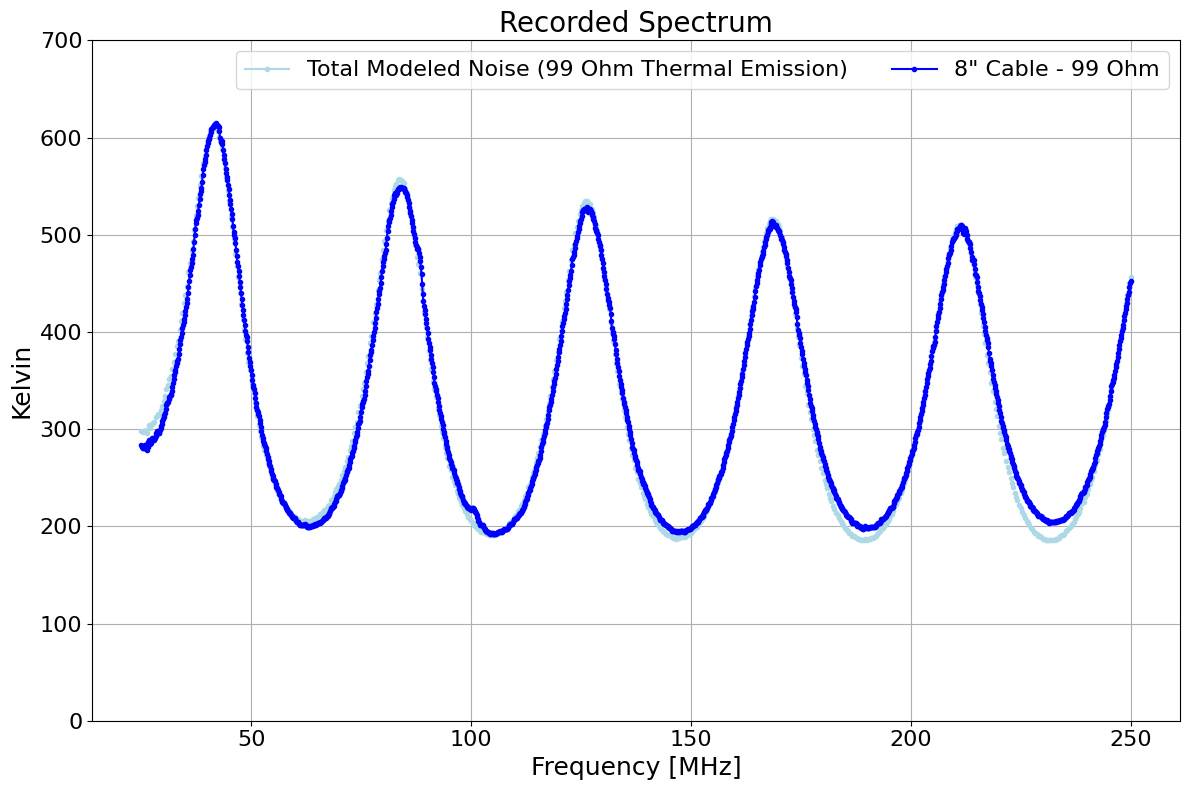

In [401]:
total_modeled = []
for jn_spec, modeled_lna_spec in zip(modeled_jn, modeled_LNA):
    total_spec = Spectrum(jn_spec.f, jn_spec.s + modeled_lna_spec.s, 
        name=f'Total Modeled Noise ({jn_spec.name})', colorcode=f'lightblue')
    total_modeled.append(total_spec)
plotter.plot_spectra([total_modeled[1], ohm_99], ms=3, marker='o', y_range=(0, 700), ylabel='Kelvin')

In [7]:
from highz_exp.reflection_proc import remove_spikes

def remove_rfi(kelvin_spec, prominence=50, clean_width=7):
    cleaned_f, cleaned_s = remove_spikes(x=kelvin_spec.f, y=kelvin_spec.s, height=50, prominence=prominence, clean_width=clean_width)
    cleaned_f, cleaned_s = remove_spikes(x=cleaned_f, y=-cleaned_s, prominence=prominence, clean_width=clean_width)
    return Spectrum(cleaned_f, -cleaned_s, name=kelvin_spec.name, colorcode=kelvin_spec.colorcode)


In [ ]:
def match_s11(s11, target_s11, tolerance=0.1, freq_window=3):
    """
    Parameters:
    s11 (rf.Network): The S11 parameters of the antenna to be matched.
    target_s11 (rf.Network): The target S11 parameters representing the desired impedance match.
    tolerance (float): The tolerance for considering a match.
    
    Returns:
    dict: A dictionary containing the best match frequency, S11 value, and the corresponding impedance.
    """ 
    
    match_mask = np.abs((np.real(s11.z[:, 0, 0]) - np.real(target_s11.z[:, 0, 0])) / np.real(target_s11.z[:, 0, 0])) < tolerance
    match_mask &= np.abs((np.imag(s11.z[:, 0, 0]) - np.imag(target_s11.z[:, 0, 0])) / np.imag(target_s11.z[:, 0, 0])) < tolerance

    matched_freqs = s11.f[match_mask]
    matched_s11_values = s11.s[match_mask, 0, 0]
    

    ntwk = rf.Network(f=matched_freqs, s=matched_s11_values[:, np.newaxis, np.newaxis])
    target_ntwk = rf.Network(f=matched_freqs, s=target_s11.s[match_mask])
    
    return ntwk, target_ntwk